# TF(TensorFlow) DATA PIPELINE

- Here we are building  tf dataset pipeline. It will extract data from multiple sources and do all ETL operation and feed data to ML model required format for training

-  This tf_dataset is a special type of Dataframe, which will support many types of operation on data

- 1st Part we did all operation on simple List of values

- 2nd part we have taken dog and cat images and read those images, shuffled, Basic Transformation, splitted as train and test and labelled all images as Cat or Dog (Y) and image values as X


# PART 1:

- 1st Part we did all operation on simple List of values

In [2]:
import tensorflow as tf

## Create tf dataset from a list

In [9]:
#cONSIDER THIS NO AS DAILY SALES NO
daily_sales_numbers = [21, 22, -108, 31, -1, 32, 34,31]

#Create TF dataset from this, it creates object
# This tf_dataset is a special type of Dataframe, which will support many types of operation on data
tf_dataset = tf.data.Dataset.from_tensor_slices(daily_sales_numbers)
tf_dataset

<TensorSliceDataset shapes: (), types: tf.int32>

## Iterate through tf dataset

In [10]:
for sales in tf_dataset:
    print(sales)

tf.Tensor(21, shape=(), dtype=int32)
tf.Tensor(22, shape=(), dtype=int32)
tf.Tensor(-108, shape=(), dtype=int32)
tf.Tensor(31, shape=(), dtype=int32)
tf.Tensor(-1, shape=(), dtype=int32)
tf.Tensor(32, shape=(), dtype=int32)
tf.Tensor(34, shape=(), dtype=int32)
tf.Tensor(31, shape=(), dtype=int32)


In [11]:
for sales in tf_dataset:
    print(sales.numpy())  # Converted value to numpy

print("\n")


21
22
-108
31
-1
32
34
31




### Iterate through elements as numpy elements 
- another way using **as_numpy_iterator**

In [12]:
for sales in tf_dataset.as_numpy_iterator():
    print(sales)

21
22
-108
31
-1
32
34
31


## Iterate through first n elements in tf dataset
- Take(n) will acts like head(n) and reads starting n lines
- skip(n) will acts like reverse of head(n) and ignors starting n lines and consider only remaining

In [7]:
for sales in tf_dataset.take(3):
    print(sales.numpy())

21
22
-108


In [13]:
for sales in tf_dataset.skip(3):
    print(sales.numpy())

31
-1
32
34
31


## Filter sales numbers that are < 0

- Filter will filters all records based on condition given inside ()
- Here lambda will iterate through each row in Dataframe and gives filterd output

In [14]:
tf_dataset = tf_dataset.filter(lambda x: x>0)

for sales in tf_dataset.as_numpy_iterator():
    print(sales)

21
22
31
32
34
31


## Convert sales numbers from USA dollars ("Dollar") to Indian Rupees (INR) Assuming 1->72 conversation rate

- Here we are doing some transformation operation like multiplication

In [15]:
tf_dataset = tf_dataset.map(lambda x: x*72)
for sales in tf_dataset.as_numpy_iterator():
    print(sales)

1512
1584
2232
2304
2448
2232


## Shuffe
- It randomly shuffles the records
- Here shuffle(3), considers window/Buffer size of 3 and does shuffling

More detail on shuffle: https://stackoverflow.com/questions/53514495/what-does-batch-repeat-and-shuffle-do-with-tensorflow-dataset

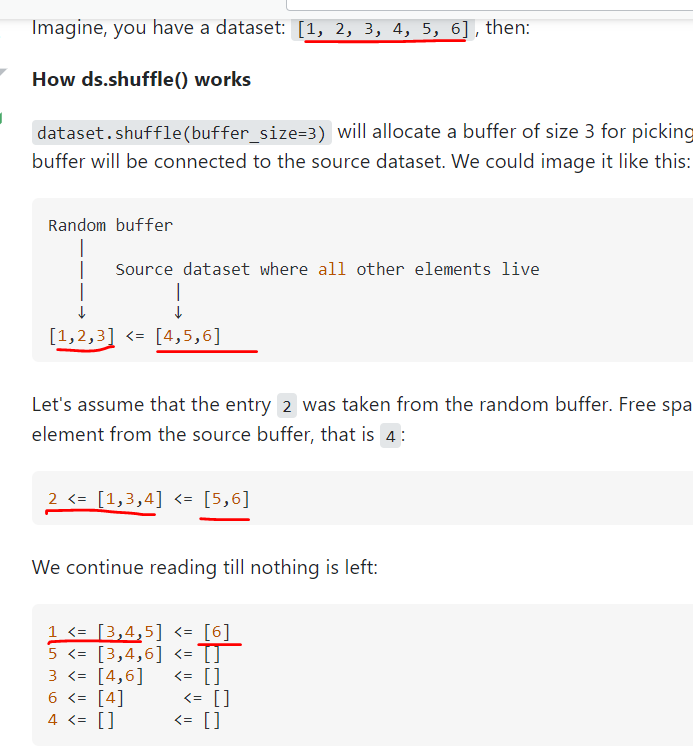

In [19]:
#Before Shuffle
for sales in tf_dataset.as_numpy_iterator():
    print(sales)

1584
1512
2304
2448
2232
2232


In [20]:
#After Shuffle
tf_dataset = tf_dataset.shuffle(2)

for sales in tf_dataset.as_numpy_iterator():
    print(sales)

2232
1512
2304
1584
2232
2448


## Batching

- This batching required in huge data running in multi GPU system/Environment, where batch wise data will be distributed in different GPU for training purpose
- It creates data as batch of that size which we mentioned

In [22]:
for sales_batch in tf_dataset.batch(4):
    print(sales_batch.numpy())

[1512 1584 2232 2232]
[2304 2448]


In [23]:
for sales_batch in tf_dataset.batch(2):
    print(sales_batch.numpy())

[2232 1512]
[2448 2232]
[1584 2304]


## Perform all of the above operations in one shot

In [24]:
# Read original data
tf_dataset = tf.data.Dataset.from_tensor_slices(daily_sales_numbers)

tf_dataset = tf_dataset.filter(lambda x: x>0).map(lambda y: y*72).shuffle(2).batch(2)
for sales in tf_dataset.as_numpy_iterator():
    print(sales)

[1584 1512]
[2232 2304]
[2448 2232]


# PART 2:

- 2nd part we have taken **dog** and **cat** images and read those images, shuffled, Basic Transformation, splitted as train and test and labelled all images as Cat or Dog (Y) and image values as X

## Images
- Read the imag data from local image folder, which has cat and dog images in 2 different subfolder cat and dog inside images folder with 6 images each

In [27]:
images_ds = tf.data.Dataset.list_files('images/*/*', shuffle=False) # Here it wont shuffle the rows, its done later

In [28]:
image_count = len(images_ds)
image_count

12

In [29]:
type(images_ds)

tensorflow.python.data.ops.dataset_ops.TensorSliceDataset

In [31]:
for file in images_ds:
    print(file.numpy())

b'images\\cat\\283944-cat-wallpaper-1920x1200-free-download.jpg'
b'images\\cat\\Beautiful_Cat_Image_Download.jpg'
b'images\\cat\\Beautiful_cats_two.jpg'
b'images\\cat\\Cat_images.jpg'
b'images\\cat\\cat12.jpg'
b'images\\cat\\white cat hd wallpaper.jpg'
b'images\\dog\\85-850715_dog-images-download.jpg'
b'images\\dog\\Dog_12.jpg'
b'images\\dog\\HQ Dog HD Wallpaper.jpg'
b'images\\dog\\cool-dog-wallpaper (1).jpg'
b'images\\dog\\dog356.jpg'
b'images\\dog\\th.jpg'


In [32]:
#1st 3 images
for file in images_ds.take(3):
    print(file.numpy())

b'images\\cat\\283944-cat-wallpaper-1920x1200-free-download.jpg'
b'images\\cat\\Beautiful_Cat_Image_Download.jpg'
b'images\\cat\\Beautiful_cats_two.jpg'


In [34]:
#It shuffles images
images_ds = images_ds.shuffle(200)
for file in images_ds.take(3):
    print(file.numpy())

b'images\\cat\\Beautiful_cats_two.jpg'
b'images\\dog\\HQ Dog HD Wallpaper.jpg'
b'images\\dog\\Dog_12.jpg'


In [36]:
# we know 2 classes are "cat","dog"
class_names = ["cat","dog"]

### Split the data into Train and Test
- Here image_count*0.8 will take starting 80% data as train and remaining as test

In [38]:
train_size = int(image_count*0.8)
train_ds = images_ds.take(train_size)
test_ds = images_ds.skip(train_size)

In [39]:
len(train_ds)

9

In [40]:
len(test_ds)

3

### Take Subfolder name as Label

In [42]:
for file in images_ds.take(3):
    print(file.numpy())

b'images\\dog\\85-850715_dog-images-download.jpg'
b'images\\cat\\Beautiful_Cat_Image_Download.jpg'
b'images\\cat\\Cat_images.jpg'


> Here we need to take subfolder name as **Y** or **Labelled** value of the data

In [44]:
#This is way of split in normal text
s = "images\\dog\\85-850715_dog-images-download.jpg"
s.split("\\")

['images', 'dog', '85-850715_dog-images-download.jpg']

In [45]:
s.split("\\")[-2]

'dog'

> Similar way split, we have **tf.strings.split()** in tensorflow framework

In [54]:
def get_label(file_path):
    import os
    parts = tf.strings.split(file_path, os.path.sep)  # Here os.path.sep --> Will seperate based on OS standard split symbol, here its //
    return parts[-2]  #Here parts will have splitted value as list, we take only 2nd value from back(Subfolder name)

In [61]:
get_label("images\\cat\\Beautiful_Cat_Image_Download.jpg")

<tf.Tensor: shape=(), dtype=string, numpy=b'cat'>

In [62]:
def process_image(file_path):
    label = get_label(file_path)
    img = tf.io.read_file(file_path) # load the raw data/image from the file as a string
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, [128, 128])
    return img, label

In [65]:
img, label = process_image("images\\cat\\Beautiful_Cat_Image_Download.jpg")
img.numpy()[:2]

array([[[ 27.5625 ,   4.5625 ,  12.5625 ],
        [ 24.71875,   3.71875,  10.71875],
        [ 28.     ,   7.     ,  14.     ],
        [ 27.     ,   6.     ,  13.     ],
        [ 26.71875,   5.71875,  14.71875],
        [ 27.     ,   6.     ,  13.     ],
        [ 25.28125,   4.28125,  13.28125],
        [ 28.     ,   5.     ,  13.     ],
        [ 29.28125,   6.28125,  14.28125],
        [ 28.     ,   9.     ,  15.     ],
        [ 27.5625 ,   6.5625 ,  13.5625 ],
        [ 29.     ,   8.     ,  15.     ],
        [ 28.     ,   7.     ,  14.     ],
        [ 28.     ,   8.     ,  10.     ],
        [ 28.     ,   8.     ,  10.     ],
        [ 30.     ,  10.     ,  12.     ],
        [ 28.71875,   8.71875,  10.71875],
        [ 29.71875,   9.71875,  11.71875],
        [ 27.71875,   7.71875,   9.71875],
        [ 28.     ,   8.     ,  10.     ],
        [ 30.15625,  10.4375 ,  12.4375 ],
        [ 29.     ,   9.     ,  11.     ],
        [ 30.     ,  10.     ,  12.     ],
        [ 3

In [66]:
label

<tf.Tensor: shape=(), dtype=string, numpy=b'cat'>

## Convert all records train and test to img, label values
- Here **train_ds.map** will apply process_image funct operation on each records and saves img and label for each record

In [67]:
train_ds = train_ds.map(process_image)
test_ds = test_ds.map(process_image)

In [68]:
train_ds

<MapDataset shapes: ((128, 128, None), ()), types: (tf.float32, tf.string)>

### Read IMG and Label value separately

- Here just 1st record img and label value are validating

In [70]:
for image, label in train_ds.take(1):
    print("****",image)
    print("****",label)

**** tf.Tensor(
[[[228.6289  190.2539  176.66016]
  [231.04297 191.82422 181.07422]
  [232.78516 193.71875 184.57031]
  ...
  [212.14453 159.66797 165.95312]
  [210.26172 157.26172 165.32422]
  [212.53125 157.375   163.84375]]

 [[186.26953 148.86328 151.42578]
  [183.875   146.5039  151.28125]
  [183.7461  145.57031 149.3125 ]
  ...
  [218.29297 168.42578 169.24219]
  [216.78516 166.78516 166.84766]
  [215.45703 164.65625 162.71875]]

 [[209.21875 163.      173.     ]
  [209.5625  163.125   174.34375]
  [208.97656 162.5664  173.73047]
  ...
  [235.82031 197.69531 202.66406]
  [233.90234 195.33984 200.77734]
  [234.94922 194.38672 198.60547]]

 ...

 [[240.625   242.33203 232.21094]
  [240.7539  242.7539  228.7539 ]
  [240.36719 242.61719 229.36719]
  ...
  [242.99219 249.3164  245.88281]
  [244.78125 250.78125 247.21875]
  [248.4375  252.      250.5625 ]]

 [[242.4375  246.17578 240.04297]
  [234.88281 240.6836  229.6875 ]
  [238.39453 247.49219 234.14844]
  ...
  [246.1914  251.25   

### Scale the X or img value which is in RGB numeric value

- Define funct scale and apply this func on train and test dataset's img, keep label as its

In [72]:
def scale(image, label):
    return image/255, label

In [73]:
train_ds = train_ds.map(scale)

In [75]:
for image, label in train_ds.take(5):
    print("****Image: ",image.numpy()[0][0]) # its huge no of numeric, so taking few sample [0][0]
    print("****Label: ",label.numpy())

****Image:  [0.00459559 0.01243873 0.00229779]
****Label:  b'cat'
****Image:  [0.09803922 0.09215686 0.04509804]
****Label:  b'dog'
****Image:  [0.10808823 0.01789216 0.04926471]
****Label:  b'cat'
****Image:  [0.896584   0.74609375 0.6927849 ]
****Label:  b'cat'
****Image:  [0.8901961 0.5686275 0.4745098]
****Label:  b'cat'


### TRAIN THE MODEL

- Pass this numeric converted **Train_X**  or **image.numpy()** and **Y** or **label.numpy()** to train the model